In [1]:
from typing import Any, Dict

import hydra
import numpy as np
import omegaconf
import torch
import pytorch_lightning as pl
import torch.nn as nn
from torch.nn import functional as F
from torch_scatter import scatter
from tqdm import tqdm

from cdvae.common.utils import PROJECT_ROOT
from cdvae.common.data_utils import (
    EPSILON, cart_to_frac_coords, mard, lengths_angles_to_volume,
    frac_to_cart_coords, min_distance_sqr_pbc)
from cdvae.pl_modules.embeddings import MAX_ATOMIC_NUM
from cdvae.pl_modules.embeddings import KHOT_EMBEDDINGS

#added by Tsach
from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator
#import Batch
from torch_geometric.data import Batch
xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)
torch.set_printoptions(threshold=50000) # use this if you want to print the entire tensor


import time
import argparse
import torch

from tqdm import tqdm
from torch.optim import Adam
from pathlib import Path
from types import SimpleNamespace
from torch_geometric.data import Batch
from torch_geometric.data.separate import separate

#import a library that allows you to reload a module
from importlib import reload

from eval_utils import load_model

all_frac_coords_stack = []
all_atom_types_stack = []
frac_coords = []
num_atoms = []
atom_types = []
lengths = []
angles = []
input_data_list = []

#my code 
list_of_idxs = []
list_of_batchs = []

import importlib 
import eval_utils
importlib.reload(eval_utils)
from eval_utils import load_model

In [2]:
import eval_utils
importlib.reload(eval_utils)
from eval_utils import load_model

In [3]:
model_path = Path("/home/gridsan/tmackey/hydra/singlerun/2023-10-29/no_encode_intensity_concat_comp_concat_neg_mask_mp_20")
model, test_loader, cfg = load_model(model_path, True)

loader = test_loader

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/hydra/experimental/compose.py:16: UserWarning: hydra.experimental.compose() is no longer experimental. Use hydra.compose()
  warnings.warn(


  0%|          | 0/9047 [00:00<?, ?it/s]

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/gridsan/tmackey/.conda/envs/cdvae/

CrystDataModule(self.datasets={'train': {'_target_': 'cdvae.pl_data.dataset.CrystDataset', 'name': 'Formation energy train', 'path': '/home/gridsan/tmackey/cdvae/data/mp_20/train.csv', 'prop': 'formation_energy_per_atom', 'niggli': True, 'primitive': False, 'graph_method': 'crystalnn', 'lattice_scale_method': 'scale_length', 'preprocess_workers': 30}, 'val': [{'_target_': 'cdvae.pl_data.dataset.CrystDataset', 'name': 'Formation energy val', 'path': '/home/gridsan/tmackey/cdvae/data/mp_20/val.csv', 'prop': 'formation_energy_per_atom', 'niggli': True, 'primitive': False, 'graph_method': 'crystalnn', 'lattice_scale_method': 'scale_length', 'preprocess_workers': 30}], 'test': [{'_target_': 'cdvae.pl_data.dataset.CrystDataset', 'name': 'Formation energy test', 'path': '/home/gridsan/tmackey/cdvae/data/mp_20/test.csv', 'prop': 'formation_energy_per_atom', 'niggli': True, 'primitive': False, 'graph_method': 'crystalnn', 'lattice_scale_method': 'scale_length', 'preprocess_workers': 30}]}, self

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/torch_geometric/deprecation.py:13: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [4]:
model.to('cuda:0')

RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

In [5]:
for idx, batch in enumerate(loader):
    print(idx)
    list_of_idxs.append(idx)
    list_of_batchs.append(batch)

idx = list_of_idxs[0]
batch = list_of_batchs[0]


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35


In [6]:
batch[2]

tensor([[21.5568, 24.9415, 35.5629,  ...,  0.0000,  0.0000,  0.0000],
        [13.3424, 15.0704, 18.0000,  ...,  0.0000,  0.0000,  0.0000],
        [15.9673, 19.6701, 19.8855,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 8.2790, 12.4131, 14.9388,  ..., 77.0272, 77.0783, 77.2516],
        [15.2867, 19.2092, 20.9772,  ...,  0.0000,  0.0000,  0.0000],
        [16.3979, 18.9564, 26.9336,  ...,  0.0000,  0.0000,  0.0000]])

In [7]:
def new_dataloader_batch_processor(batch): 
    batch_reserve = batch
    xrd_int = batch_reserve[1]
    xrd_loc = batch_reserve[2]
    atom_spec = batch_reserve[3]
    disc_sim_xrd = batch_reserve[4]
    batch = batch[0]
    return batch_reserve, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, batch

batch_reserve, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, batch = new_dataloader_batch_processor(batch)

batch_all_frac_coords = []
batch_all_atom_types = []
batch_frac_coords, batch_num_atoms, batch_atom_types = [], [], []
batch_lengths, batch_angles = [], []


In [8]:
import matplotlib.pyplot as plt

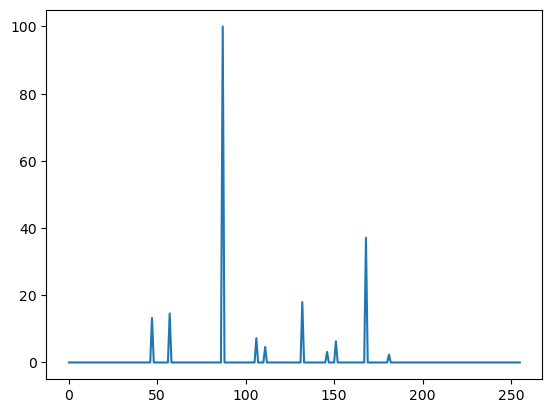

In [9]:
plt.plot(disc_sim_xrd[0])

In [10]:
_, _, z = model.encode(batch, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, testing = True)

dropout is not being used
z is of shape: torch.Size([256, 256])
z is tensor([[21.5568, 24.9415, 35.5629,  ...,  0.0000,  0.0000,  0.0000],
        [13.3424, 15.0704, 18.0000,  ...,  0.0000,  0.0000,  0.0000],
        [15.9673, 19.6701, 19.8855,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 8.2790, 12.4131, 14.9388,  ...,  0.0000,  0.0000,  0.0000],
        [15.2867, 19.2092, 20.9772,  ...,  0.0000,  0.0000,  0.0000],
        [16.3979, 18.9564, 26.9336,  ...,  0.0000,  0.0000,  0.0000]])


In [14]:
z[0] 
#recall that the model concatenates the atomic composition information and therefore also gets rid of the last 56 of the input simulated xrd

tensor([ 21.5568,  24.9415,  35.5629,  41.9669,  43.9277,  51.1742,  56.1509,
         57.7447,  63.8686,  68.2545,  75.2911,  79.3994,  80.7556,  86.1362,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,
          0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.00

In [15]:
#number of steps set unusually low to get a rough estimate of performance
ld_kwargs = SimpleNamespace(n_step_each=10,
                                step_lr=1e-4,
                                min_sigma=0,
                                save_traj=False,
                                disable_bar=False)

In [17]:
force_num_atoms = True
                
gt_num_atoms = batch.num_atoms

gt_atom_types = None

# #print out the arguments into the langevin_dynamics function
# print("z: ", z)
# print("ld_kwargs: ", ld_kwargs)
# print("gt_num_atoms: ", gt_num_atoms)
# print("gt_atom_types: ", gt_atom_types)

outputs = model.langevin_dynamics(
    z, ld_kwargs, gt_num_atoms, gt_atom_types, atom_spec)

/home/gridsan/tmackey/cdvae/cdvae/common/data_utils.py:625: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float)


RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx